# COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset

### Imports

In [ ]:
import random
import time
from typing import Tuple, Dict
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import time

### Set Seed

In [64]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

### Data Loading

In [65]:
def get_xray_loaders(
    dataDir: str,
    seed: int,
    batch_size: int = 32,
) -> Tuple[DataLoader, DataLoader]:
    set_seed(seed)
 
    transform = T.Compose([
        T.Resize((64, 64)),
        T.ToTensor()
    ])
 
    fullDataset = torchvision.datasets.ImageFolder(root=dataDir, transform=transform)
 
    trainIndices = []
    testIndices  = []
 
    for classIdx in range(len(fullDataset.classes)):
 
        classIndices = []
        for i in range(len(fullDataset.samples)):
            _, label = fullDataset.samples[i]
            if label == classIdx:
                classIndices.append(i)
 
        random.shuffle(classIndices)
 
        splitIdx = int(len(classIndices) * 0.7)
 
        trainIndices += classIndices[:splitIdx]
        testIndices  += classIndices[splitIdx:]
 
    trainDataset = Subset(fullDataset, trainIndices)
    testDataset  = Subset(fullDataset, testIndices)
 
    train_loader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(testDataset,  batch_size=batch_size, shuffle=False)
 
    print(f"Train: {len(trainDataset)} | Test: {len(testDataset)}")
    return train_loader, test_loader

In [66]:
train_loader, test_loader = get_xray_loaders(dataDir="data/", seed=0)

Train: 3659 | Test: 1569


## MLP Model

In [67]:
#2 hidden layers
class MLP1(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.layer1 = nn.Linear(12288, 512)
        self.bn1    = nn.BatchNorm1d(512)

        self.layer2 = nn.Linear(512, 256)
        self.bn2    = nn.BatchNorm1d(256)

        self.layer3 = nn.Linear(256, 3)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = self.flatten(x)

        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer3(x)
        return x

#3 hidden layers
class MLP2(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.layer1 = nn.Linear(12288, 512)
        self.bn1    = nn.BatchNorm1d(512)

        self.layer2 = nn.Linear(512, 256)
        self.bn2    = nn.BatchNorm1d(256)

        self.layer3 = nn.Linear(256, 128)
        self.bn3    = nn.BatchNorm1d(128)

        self.layer4 = nn.Linear(128, 3)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = self.flatten(x)

        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer4(x)
        return x

### Training

In [68]:
def train_one_epoch_MLP(model, loader, optimizer, device) -> Dict[str, float]:
    model.train()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss = lossFunction(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#train MLP1
set_seed(0)
mlp1Model     = MLP1(dropout_p=0.3).to(device)
mlp1Optimizer = torch.optim.Adam(mlp1Model.parameters(), lr=1e-3)

mlp1LossHistory = []
mlp1AccHistory  = []

epochs = 20
print("Training MLP1")
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_MLP(mlp1Model, train_loader, mlp1Optimizer, device)
    mlp1LossHistory.append(trainMetrics['loss'])
    mlp1AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")

Using device: cpu
Training MLP1
Epoch 1/20 | Loss: 0.5331 | Acc: 0.8713


KeyboardInterrupt: 

In [ ]:
#train MLP2
set_seed(0)
mlp2Model     = MLP2(dropout_p=0.3).to(device)
mlp2Optimizer = torch.optim.Adam(mlp2Model.parameters(), lr=1e-3)

mlp2LossHistory = []
mlp2AccHistory  = []

print("Training MLP2")
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_MLP(mlp2Model, train_loader, mlp2Optimizer, device)
    mlp2LossHistory.append(trainMetrics['loss'])
    mlp2AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")

Training MLP2
Epoch 1/20 | Loss: 0.5559 | Acc: 0.8636
Epoch 2/20 | Loss: 0.4705 | Acc: 0.9087
Epoch 3/20 | Loss: 0.4395 | Acc: 0.9251
Epoch 4/20 | Loss: 0.4349 | Acc: 0.9317
Epoch 5/20 | Loss: 0.4084 | Acc: 0.9494
Epoch 6/20 | Loss: 0.4096 | Acc: 0.9412
Epoch 7/20 | Loss: 0.3950 | Acc: 0.9519
Epoch 8/20 | Loss: 0.3964 | Acc: 0.9511
Epoch 9/20 | Loss: 0.3915 | Acc: 0.9535
Epoch 10/20 | Loss: 0.3904 | Acc: 0.9560
Epoch 11/20 | Loss: 0.3817 | Acc: 0.9604
Epoch 12/20 | Loss: 0.3794 | Acc: 0.9598
Epoch 13/20 | Loss: 0.3673 | Acc: 0.9686
Epoch 14/20 | Loss: 0.3661 | Acc: 0.9680
Epoch 15/20 | Loss: 0.3623 | Acc: 0.9688
Epoch 16/20 | Loss: 0.3590 | Acc: 0.9740
Epoch 17/20 | Loss: 0.3565 | Acc: 0.9749
Epoch 18/20 | Loss: 0.3552 | Acc: 0.9727
Epoch 19/20 | Loss: 0.3532 | Acc: 0.9721
Epoch 20/20 | Loss: 0.3475 | Acc: 0.9795


### Comparison of MLP training vs. testing accuracy

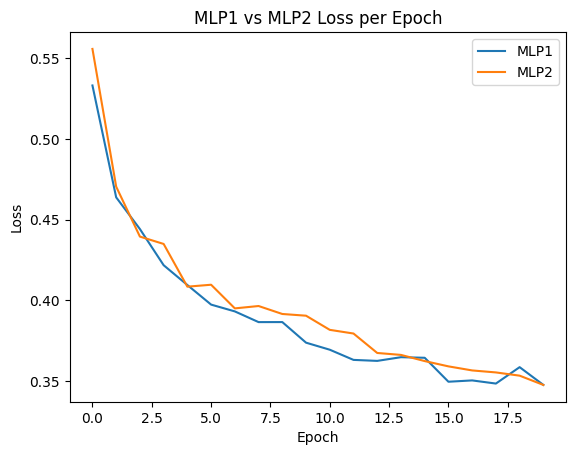

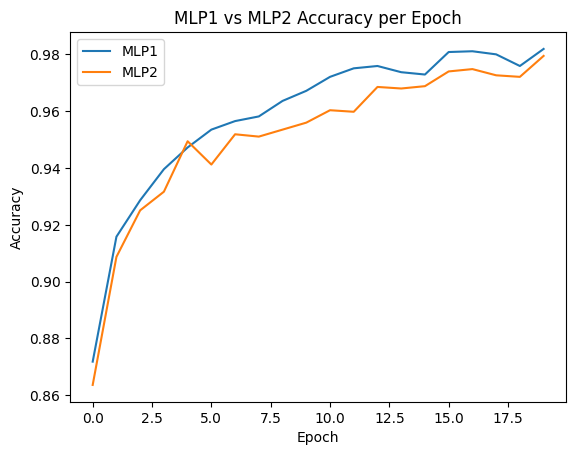

In [ ]:
plt.plot(mlp1LossHistory, label="MLP1")
plt.plot(mlp2LossHistory, label="MLP2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP1 vs MLP2 Loss per Epoch")
plt.legend()
plt.show()

plt.plot(mlp1AccHistory, label="MLP1")
plt.plot(mlp2AccHistory, label="MLP2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP1 vs MLP2 Accuracy per Epoch")
plt.legend()
plt.show()

### Evaluation

In [ ]:
@torch.no_grad()
def evaluate_MLP(model, loader, device) -> Dict[str, float]:
    model.eval()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss= lossFunction(outputs, labels)
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [ ]:
start = time.perf_counter()
mlp1TestMetrics = evaluate_MLP(mlp1Model, test_loader, device)
t1 = time.perf_counter() - start
print(f"MLP1 Test Loss: {mlp1TestMetrics['loss']:.4f} | MLP1 Test Acc: {mlp1TestMetrics['acc']:.4f}")
print(f"Runtime MLP1: {t1} sec")

start2 = time.perf_counter()
mlp2TestMetrics = evaluate_MLP(mlp2Model, test_loader, device)
t2 = time.perf_counter() - start2
print(f"MLP2 Test Loss: {mlp2TestMetrics['loss']:.4f} | MLP2 Test Acc: {mlp2TestMetrics['acc']:.4f}")
print(f"Runtime MLP2: {t2} sec")

MLP1 Test Loss: 0.5848 | MLP1 Test Acc: 0.8317
Runtime MLP1: 4.5197849000032875 sec
MLP2 Test Loss: 0.3855 | MLP2 Test Acc: 0.9535
Runtime MLP2: 4.26151309999841 sec


### Confusion Matrix for MLP

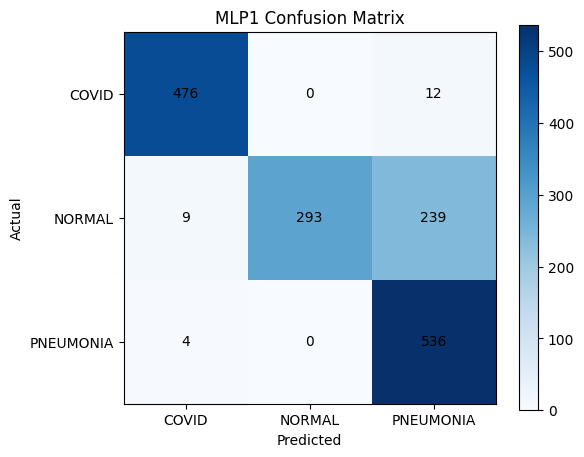

              precision    recall  f1-score   support

       COVID       0.97      0.98      0.97       488
      NORMAL       1.00      0.54      0.70       541
   PNEUMONIA       0.68      0.99      0.81       540

    accuracy                           0.83      1569
   macro avg       0.88      0.84      0.83      1569
weighted avg       0.88      0.83      0.82      1569



In [ ]:
allPreds  = []
allLabels = []

mlp1Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = mlp1Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("MLP1 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()
print(classification_report(allLabels, allPreds, target_names=classNames))

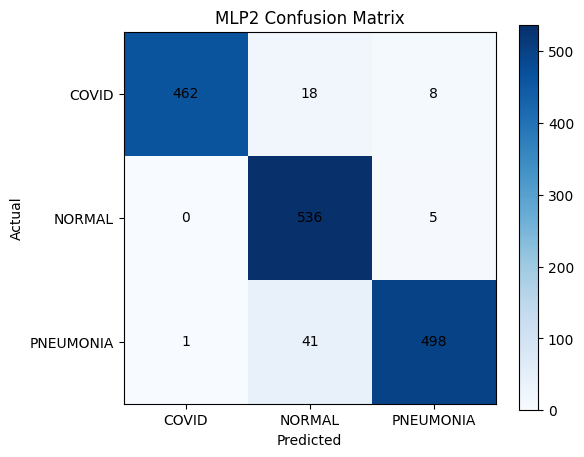

              precision    recall  f1-score   support

       COVID       1.00      0.95      0.97       488
      NORMAL       0.90      0.99      0.94       541
   PNEUMONIA       0.97      0.92      0.95       540

    accuracy                           0.95      1569
   macro avg       0.96      0.95      0.95      1569
weighted avg       0.96      0.95      0.95      1569



In [ ]:
allPreds  = []
allLabels = []

mlp2Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = mlp2Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("MLP2 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()
print(classification_report(allLabels, allPreds, target_names=classNames))

## CNN Model

In [ ]:
class CNN1(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(16384, 256)
        self.fc2     = nn.Linear(256, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


class CNN2(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3,   out_channels=32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32,  out_channels=64,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(8192, 256)
        self.fc2     = nn.Linear(256, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

### Training

In [ ]:
def train_one_epoch_CNN(model, loader, optimizer, device) -> Dict[str, float]:
    model.train()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss    = lossFunction(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [ ]:
#train CNN1
set_seed(0)
cnn1Model = CNN1(dropout_p=0.3).to(device)
cnn1Optimizer = torch.optim.Adam(cnn1Model.parameters(), lr=1e-3)

cnn1LossHistory = []
cnn1AccHistory  = []

epochs = 20
print("Training CNN1")
start = time.perf_counter()
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_CNN(cnn1Model, train_loader, cnn1Optimizer, device)
    cnn1LossHistory.append(trainMetrics['loss'])
    cnn1AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")
runtime = time.perf_counter() - start
print(f"Runtime: {runtime} sec")

Training CNN1
Epoch 1/20 | Loss: 0.6404 | Acc: 0.7956
Epoch 2/20 | Loss: 0.4439 | Acc: 0.9284
Epoch 3/20 | Loss: 0.4134 | Acc: 0.9426
Epoch 4/20 | Loss: 0.3885 | Acc: 0.9568
Epoch 5/20 | Loss: 0.3787 | Acc: 0.9637
Epoch 6/20 | Loss: 0.3699 | Acc: 0.9702
Epoch 7/20 | Loss: 0.3556 | Acc: 0.9784
Epoch 8/20 | Loss: 0.3459 | Acc: 0.9839
Epoch 9/20 | Loss: 0.3439 | Acc: 0.9831
Epoch 10/20 | Loss: 0.3337 | Acc: 0.9896
Epoch 11/20 | Loss: 0.3275 | Acc: 0.9923
Epoch 12/20 | Loss: 0.3260 | Acc: 0.9918
Epoch 13/20 | Loss: 0.3229 | Acc: 0.9943
Epoch 14/20 | Loss: 0.3170 | Acc: 0.9962
Epoch 15/20 | Loss: 0.3165 | Acc: 0.9956
Epoch 16/20 | Loss: 0.3114 | Acc: 0.9978
Epoch 17/20 | Loss: 0.3103 | Acc: 0.9986
Epoch 18/20 | Loss: 0.3069 | Acc: 0.9989
Epoch 19/20 | Loss: 0.3059 | Acc: 0.9995
Epoch 20/20 | Loss: 0.3058 | Acc: 0.9992
Runtime: 436.9335474999971 sec


In [ ]:
#train CNN2
set_seed(0)
cnn2Model     = CNN2(dropout_p=0.3).to(device)
cnn2Optimizer = torch.optim.Adam(cnn2Model.parameters(), lr=1e-3)

cnn2LossHistory = []
cnn2AccHistory  = []

print("\nTraining CNN2")
start = time.perf_counter()
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_CNN(cnn2Model, train_loader, cnn2Optimizer, device)
    cnn2LossHistory.append(trainMetrics['loss'])
    cnn2AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")
runtime = time.perf_counter() - start
print(f"Runtime: {runtime} sec")


Training CNN2
Epoch 1/20 | Loss: 0.6142 | Acc: 0.8073
Epoch 2/20 | Loss: 0.4480 | Acc: 0.9232
Epoch 3/20 | Loss: 0.4180 | Acc: 0.9445
Epoch 4/20 | Loss: 0.4004 | Acc: 0.9527
Epoch 5/20 | Loss: 0.3769 | Acc: 0.9669
Epoch 6/20 | Loss: 0.3698 | Acc: 0.9680
Epoch 7/20 | Loss: 0.3590 | Acc: 0.9732
Epoch 8/20 | Loss: 0.3525 | Acc: 0.9765
Epoch 9/20 | Loss: 0.3462 | Acc: 0.9836
Epoch 10/20 | Loss: 0.3399 | Acc: 0.9855
Epoch 11/20 | Loss: 0.3341 | Acc: 0.9874
Epoch 12/20 | Loss: 0.3296 | Acc: 0.9893
Epoch 13/20 | Loss: 0.3262 | Acc: 0.9910
Epoch 14/20 | Loss: 0.3240 | Acc: 0.9926
Epoch 15/20 | Loss: 0.3180 | Acc: 0.9954
Epoch 16/20 | Loss: 0.3150 | Acc: 0.9954
Epoch 17/20 | Loss: 0.3110 | Acc: 0.9973
Epoch 18/20 | Loss: 0.3098 | Acc: 0.9975
Epoch 19/20 | Loss: 0.3061 | Acc: 0.9986
Epoch 20/20 | Loss: 0.3060 | Acc: 0.9984
Runtime: 402.2250525999989 sec


### Comparison of CNN training vs. testing accuracy

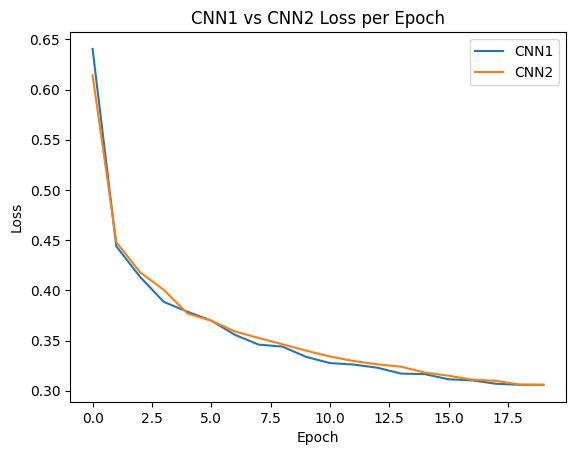

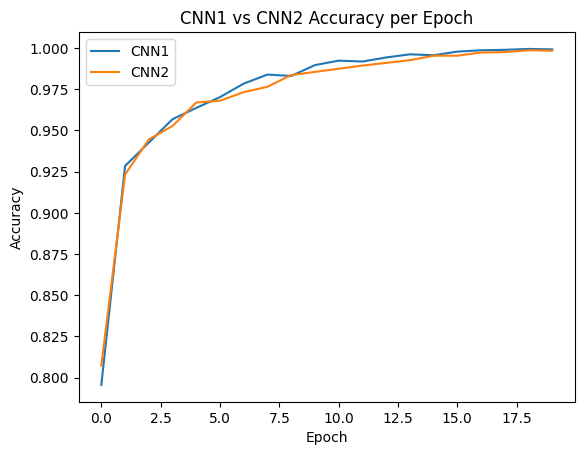

In [ ]:
plt.plot(cnn1LossHistory, label="CNN1")
plt.plot(cnn2LossHistory, label="CNN2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN1 vs CNN2 Loss per Epoch")
plt.legend()
plt.show()

plt.plot(cnn1AccHistory, label="CNN1")
plt.plot(cnn2AccHistory, label="CNN2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN1 vs CNN2 Accuracy per Epoch")
plt.legend()
plt.show()

### Evaluation

In [ ]:
@torch.no_grad()
def evaluate_CNN(model, loader, device) -> Dict[str, float]:
    model.eval()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss    = lossFunction(outputs, labels)
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [ ]:
cnn1TestMetrics = evaluate_CNN(cnn1Model, test_loader, device)
print(f"CNN1 Test Loss: {cnn1TestMetrics['loss']:.4f} | CNN1 Test Acc: {cnn1TestMetrics['acc']:.4f}")
cnn2TestMetrics = evaluate_CNN(cnn2Model, test_loader, device)
print(f"CNN2 Test Loss: {cnn2TestMetrics['loss']:.4f} | CNN2 Test Acc: {cnn2TestMetrics['acc']:.4f}")

CNN1 Test Loss: 0.3436 | CNN1 Test Acc: 0.9751
CNN2 Test Loss: 0.3482 | CNN2 Test Acc: 0.9745


### Confusion Matric for CNN

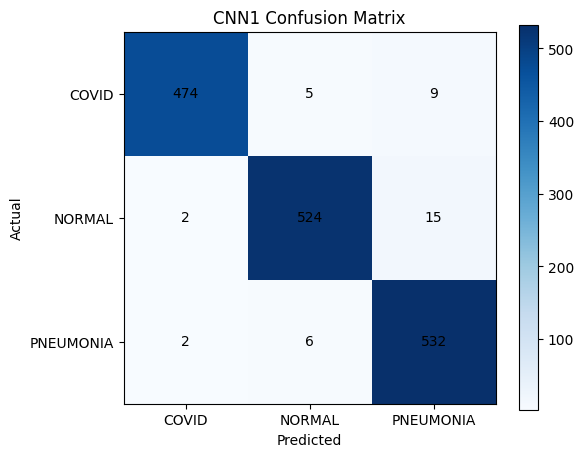

              precision    recall  f1-score   support

       COVID       0.99      0.97      0.98       488
      NORMAL       0.98      0.97      0.97       541
   PNEUMONIA       0.96      0.99      0.97       540

    accuracy                           0.98      1569
   macro avg       0.98      0.98      0.98      1569
weighted avg       0.98      0.98      0.98      1569



In [ ]:
allPreds  = []
allLabels = []

cnn1Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn1Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("CNN1 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))

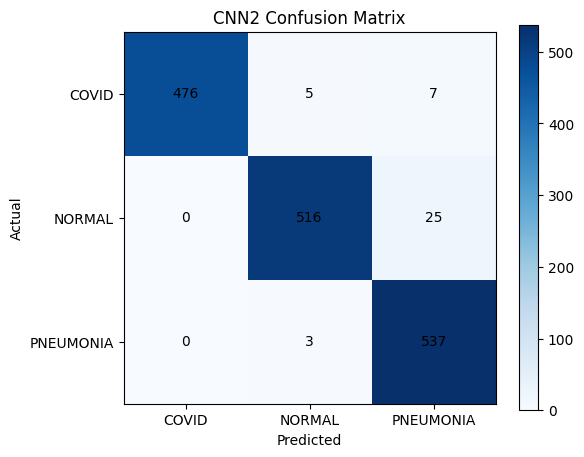

              precision    recall  f1-score   support

       COVID       1.00      0.98      0.99       488
      NORMAL       0.98      0.95      0.97       541
   PNEUMONIA       0.94      0.99      0.97       540

    accuracy                           0.97      1569
   macro avg       0.98      0.97      0.98      1569
weighted avg       0.98      0.97      0.97      1569



In [ ]:
allPreds  = []
allLabels = []

cnn2Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn2Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("CNN2 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))

## KNN

In [ ]:
def extract_features(dataloader):
    all_features, all_labels = [], []
    for images, labels in dataloader:
        flat = images.view(images.size(0), -1).numpy()
        all_features.append(flat)
        all_labels.append(labels.numpy())
    return np.vstack(all_features), np.concatenate(all_labels)

print("Extracting features...")
X_train, y_train = extract_features(train_loader)
X_test,  y_test  = extract_features(test_loader)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

In [ ]:
K = [1, 3, 5, 10, 20, 50]
for k in K:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train, y_train)
    start = time.perf_counter()
    y_pred = knn.predict(X_test)
    elapsed = time.perf_counter() - start

    print(f"\nAccuracy for {k} neigbors: {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nRuntime: {elapsed} seconds")

## KNN with addition of PCA

In [ ]:
pca_full = PCA().fit(X_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.searchsorted(cumvar, 0.95) + 1

N_COMPONENTS = n_95
pca = PCA(n_components=N_COMPONENTS, random_state=0)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

K = [1, 3, 5, 10]
for k in K:
    knn_pca = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn_pca.fit(X_train_pca, y_train)

    y_pred_pca = knn_pca.predict(X_test_pca)

    acc_raw = accuracy_score(y_test, y_pred)
    print(f"\nData for {k} neighbors")
    print(f"Accuracy (raw): {acc_raw}")

    acc_pca = accuracy_score(y_test, y_pred_pca)
    print(f"Accuracy (PCA): {acc_pca}")
    print(f"Difference: {acc_pca - acc_raw}")

    start = time.perf_counter()
    knn.predict(X_test)
    t_raw = (time.perf_counter() - start)

    start = time.perf_counter()
    knn_pca.predict(X_test_pca)
    t_pca = (time.perf_counter() - start)

    print(f"\nRuntime (raw) : {t_raw} seconds")
    print(f"Runtime (PCA) : {t_pca} seconds")
    print(f"Speedup: {t_raw / t_pca}x")

### Using different distance metrics

In [ ]:
metrics = ["euclidean", "manhattan", "cosine"]
K = [1, 3, 5, 10, 20, 50]
results = {m: {"acc_raw": [], "acc_pca": [], "t_raw": [], "t_pca": []} for m in metrics}

for metric in metrics:
    for k in K:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=-1)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc_raw = accuracy_score(y_test, y_pred)

        knn_pca = KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=-1)
        knn_pca.fit(X_train_pca, y_train)
        y_pred_pca = knn_pca.predict(X_test_pca)
        acc_pca = accuracy_score(y_test, y_pred_pca)

        print(f"\nData for {k} neighbors and {metric} metric")
        print(f"Accuracy (raw): {acc_raw}")
        print(f"Accuracy (PCA): {acc_pca}")
        print(f"Difference:     {acc_pca - acc_raw}")

        start = time.perf_counter()
        knn.predict(X_test)
        t_raw = time.perf_counter() - start

        start = time.perf_counter()
        knn_pca.predict(X_test_pca)
        t_pca = time.perf_counter() - start

        print(f"Runtime (raw):  {t_raw:.4f}s")
        print(f"Runtime (PCA):  {t_pca:.4f}s")
        print(f"Speedup:        {t_raw / t_pca:.2f}x")
        results[metric]["acc_raw"].append(acc_raw)
        results[metric]["acc_pca"].append(acc_pca)
        results[metric]["t_raw"].append(t_raw)
        results[metric]["t_pca"].append(t_pca)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = {"euclidean": "#378ADD", "manhattan": "#1D9E75", "cosine": "#D85A30"}
markers = {"euclidean": "o", "manhattan": "s", "cosine": "^"}

# 1. PCA accuracy across k and metrics
ax = axes[0]
for metric in metrics:
    ax.plot(K, results[metric]["acc_pca"], marker=markers[metric],
            label=metric, color=colors[metric])
ax.set_xlabel("k"); ax.set_ylabel("Accuracy")
ax.set_title("PCA accuracy by k and metric")
ax.set_xticks(K); ax.legend(); ax.set_ylim(0, 1)

# 2. PCA inference time across k and metrics
ax = axes[1]
for metric in metrics:
    ax.plot(K, results[metric]["t_pca"], marker=markers[metric],
            label=metric, color=colors[metric])
ax.set_xlabel("k"); ax.set_ylabel("Time (s)")
ax.set_title("PCA inference time by k and metric")
ax.set_xticks(K); ax.legend()

# 3. Explained variance curve
ax = axes[2]
ax.plot(np.arange(1, len(cumvar)+1), cumvar, color="#888", linewidth=1.5)
ax.axhline(0.95, color="#D85A30", linewidth=1, linestyle="--", label="95% threshold")
ax.axvline(n_95, color="#378ADD", linewidth=1, linestyle="--", label=f"n={n_95} components")
ax.set_xlabel("Number of components"); ax.set_ylabel("Cumulative explained variance")
ax.set_title("Explained variance curve"); ax.legend()

plt.tight_layout()
plt.savefig("knn_pca.png", dpi=150, bbox_inches="tight")
plt.show()